# Machine Learning-based Molecular Dynamics (MD)


This notebook runs an NVT MD simulation of a mixed OH-H₂O overlayer on a Pt(111) surface using SpookyNet, a message-passing neural network, as the force calculator. The system is relevant to the oxygen reduction reaction, where the electrode surface under operating conditions is covered by a mixture of adsorbed OH and water rather than a bare metal. The simulation runs for 1000 steps at 10 K with a 1 fs timestep (1 ps total) using the Bussi stochastic velocity rescaling thermostat, which maintains the correct NVT statistical ensemble. The trajectory is then analyzed in several ways: nearest-neighbor distance histograms verify structural stability; a scatter plot of Pt-O-H angle vs O-H bond length probes whether surface binding geometry correlates with bond strength; a two-descriptor classifier separates OH from H₂O species based on H-coordination number and out-of-plane spread; a Pt-O vs O-H bond length correlation tests the trans-influence; and a velocity distribution confirms the thermostat is functioning correctly.

In [1]:
%%capture
!git clone https://github.com/OUnke/SpookyNet.git
%cd SpookyNet
!pip install .

In [2]:
%%capture
%cd /content/
!pip install torch ase

In [3]:
method='spookynet'
prefix='Pt-OH-H2O'

In [4]:
#############
##-Imports-##
#############

##-Standard library-##
import random

##-Scientific packages-##
import numpy as np
import matplotlib.pyplot as plt
import torch

##-ASE-##
from ase.constraints import FixAtoms
from ase.io import read, Trajectory
from ase.units import fs
from ase.visualize import view

##-ASE MD-##
from ase.md import MDLogger
from ase.md.bussi import Bussi
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

##-ASE neighbour list-##
from ase.neighborlist import NeighborList

##-SpookyNet-##
from spookynet.spookynet_calculator import SpookyNetCalculator

You will run a simplified version of Molecylar Dynamics simultion and its analysis. For a more reasilitc example, take a look at https://doi.org/10.1016/j.cattod.2012.06.001.

The .traj file contains a pre-built atomic structure: a Pt(111) slab with an OH–H₂O overlayer on top. The -1 index reads the last frame (the most relaxed geometry). view() renders it interactively in the notebook.

In [5]:
%%capture
!wget https://github.com/doublelayer/test_models/raw/refs/heads/main/Pt-w/Pt-OH-H2O.traj

Let us take a look on the model. It is the so-called mixed OH–H₂O overlayer ontop of Pt(111) surface.

In [6]:
atoms = read(f'{prefix}.traj', -1)
view(atoms, viewer='x3d')

The Pt slab has multiple layers. Tags 2 and 3 mark the two bottom layers, which are frozen in place. This mimics bulk behavior, in reality, the deep bulk doesn't move on MD timescales, and prevents the slab from drifting or deforming artificially.

In [7]:
indices = [atom.index for atom in atoms if atom.tag in (2, 3)]
atoms.set_constraint(FixAtoms(indices))
atoms.set_pbc(True)

This identifies H₂O molecules by finding oxygen atoms with exactly two hydrogen neighbors closer than 1.0 Å, then tags both the O and its two H atoms with tag=4. This label is used later to distinguish H₂O from OH groups during analysis.

In [8]:
for i, at_i in enumerate(atoms):
  if at_i.symbol != 'O':
    continue

  h_neighbors = []

  for j, at_j in enumerate(atoms):
    if at_j.symbol == 'H' and atoms.get_distance(i, j) < 1.0:
      h_neighbors.append(j)

  if len(h_neighbors) == 2:
    atoms[i].tag = 4

    for j in h_neighbors:
      atoms[j].tag = 4

This loads the pre-trained SpookyNet neural network from a .pth file and attaches it to the atomic structure. From this point on, whenever ASE needs forces or energies (e.g., to move atoms), it queries this network instead of running DFT. The charge=0, magmom=0 settings define the electronic state of the system.


In [9]:
calc = SpookyNetCalculator(load_from='SpookyNet/parameters.pth', charge=0, magmom=0)
atoms.calc = calc

/usr/local/lib/python3.12/dist-packages/ase/calculators/calculator.py:620: FutureWarning: The keyword "ignore_bad_restart_file" is deprecated and will be removed in a future version of ASE.  Passing more than one positional argument to Calculator is also deprecated and will stop functioning in the future.  Please pass arguments by keyword (key=value) except optionally the "restart" keyword.
  warnings.warn(


Three things happen here:

MaxwellBoltzmannDistribution assigns initial velocities to atoms consistent with the target temperature, this is the standard way to "heat up" a system at the start of MD.

Bussi is a stochastic velocity rescaling thermostat that keeps the simulation at a constant temperature (NVT ensemble) while preserving proper statistical mechanics, unlike simpler rescaling schemes.

timestep=1.0*fs means each MD step advances time by 1 femtosecond (10⁻¹⁵ s). With 1000 steps, the total simulation time is 1 picosecond.

random.random.seed fixes the starting point of the pseudo-random number generator. Without it, the RNG initializes from system entropy, so every run produces different numbers.

In [10]:
##-This takes around 3 min-##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

temperature = 10
steps = 1000

MaxwellBoltzmannDistribution(atoms, temperature_K=temperature, force_temp=True)

dyn = Bussi(atoms, timestep=1.0 * fs, temperature_K=temperature, taut=0.5 * fs)

traj = Trajectory(f'{prefix}_MD.traj', 'w', atoms)
logger = MDLogger(dyn, atoms, f'{prefix}_MD.log', mode='w', header=True, stress=False, peratom=True)

dyn.attach(logger, interval=10)
dyn.attach(traj.write, interval=10)

dyn.run(steps)

/tmp/ipykernel_614/299402131.py:9: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(atoms, temperature_K=temperature, force_temp=True)
/usr/local/lib/python3.12/dist-packages/spookynet/spookynet_calculator.py:165: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  else torch.tensor([atoms.cell], dtype=self.dtype),


True

In [11]:
traj = Trajectory(f'{prefix}_MD.traj')

print('Number of frames:', len(traj))
print('Number of atoms:', len(traj[0]))
print(traj[0])

Number of frames: 101
Number of atoms: 168
Atoms(symbols='H36O24Pt108', pbc=True, cell=[16.6311514935076, 14.402999687565085, 24.526426110446664], momenta=..., tags=..., constraint=FixAtoms(indices=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151]), calculator=SinglePointCalculator(...))


It builds a neighbor list for the final trajectory frame, treating any two atoms within 6 Å of each other (3 Å per atom, summed) as neighbors.

In [12]:
atoms0 = traj[-1]
n_atoms = len(atoms0)
cutoffs = [3.0] * n_atoms
nl = NeighborList(cutoffs, self_interaction=False, bothways=True)

Let us take a look on the model after the MD simulation.

In [13]:
view(atoms0, viewer='x3d')

For every atom in every frame, this finds its closest neighbour using a NeighborList (with a 3.0 Å cutoff) and histograms those distances. The result tells you whether bond lengths are physically reasonable and if the structure stays intact during the simulation.



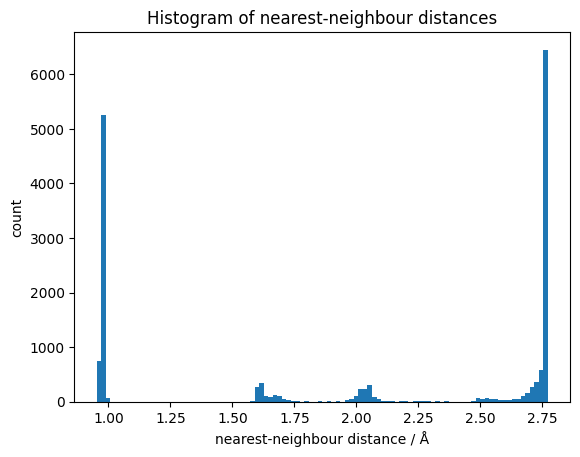

In [14]:
all_nn_dist = []

for atoms in traj:
  nl.update(atoms) ##-Update with current positions, cell and PBC-##

  cell = atoms.get_cell()
  positions = atoms.positions

  for i in range(n_atoms):
    indices, offsets = nl.get_neighbors(i)

    if len(indices) == 0:
      continue

    disp = positions[indices] + offsets @ cell - positions[i]
    dists = np.linalg.norm(disp, axis=1)

    all_nn_dist.append(dists.min())

all_nn_dist = np.array(all_nn_dist)

plt.hist(all_nn_dist, bins=100)
plt.xlabel('nearest-neighbour distance / Å')
plt.ylabel('count')
plt.title('Histogram of nearest-neighbour distances')
plt.show()

For each O atom that has both a Pt neighbour (within 3.0 Å) and an H neighbour (within 1.2 Å), this computes the ∠(Pt–O–H) angle and the O–H bond length and looks for a correlation. The physical motivation: if OH tilts toward or away from the surface, it might stretch or compress the O–H bond, a signature of the surface trans-influence. Data is split by tag (blue = all O, red = H₂O-tagged O).

Correlation(angle, O-H length) for all O = -0.002165912324684728
Correlation(angle, O-H length) for O (tag=4) = 0.22972849262977244


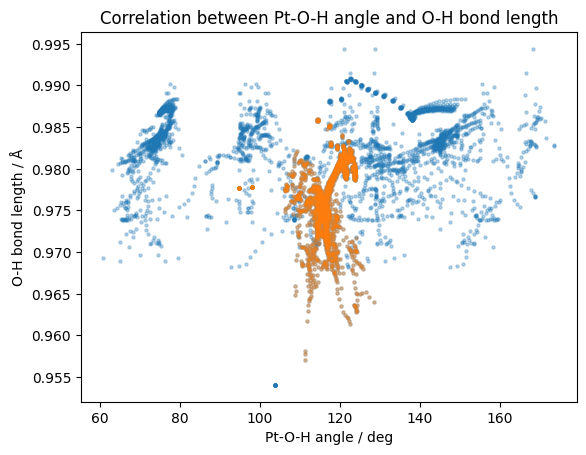

In [15]:
angles = []
bond_lengths = [] ##-O-H bond length-##

angles_tag4 = []
bond_lengths_tag4 = []

for atoms in traj:
  nl.update(atoms)

  cell = atoms.get_cell()
  pos = atoms.positions
  symbols = atoms.get_chemical_symbols()
  tags = atoms.get_tags()

  for i in range(n_atoms):
    if symbols[i] != 'O':
      continue

    indices, offsets = nl.get_neighbors(i)

    if len(indices) == 0:
      continue

    disp = pos[indices] + offsets @ cell - pos[i]
    dists = np.linalg.norm(disp, axis=1)

    pt_indices = [
      j for j, idx in enumerate(indices)
      if symbols[idx] == 'Pt' and dists[j] < 3.0
    ]

    h_indices = [
      j for j, idx in enumerate(indices)
      if symbols[idx] == 'H' and dists[j] < 1.2
    ]

    for jp in pt_indices:
      for jh in h_indices:
        v_pt = disp[jp]
        v_h = disp[jh]
        d_oh = np.linalg.norm(v_h)

        if d_oh == 0:
          continue

        cos_theta = np.dot(v_pt, v_h) / (np.linalg.norm(v_pt) * np.linalg.norm(v_h))
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta_deg = np.degrees(np.arccos(cos_theta))

        angles.append(theta_deg)
        bond_lengths.append(d_oh)

        if tags[i] == 4:
          angles_tag4.append(theta_deg)
          bond_lengths_tag4.append(d_oh)

angles = np.array(angles)
bond_lengths = np.array(bond_lengths)
angles_tag4 = np.array(angles_tag4)
bond_lengths_tag4 = np.array(bond_lengths_tag4)

corr_all = np.corrcoef(angles, bond_lengths)[0, 1]

print('Correlation(angle, O-H length) for all O =', corr_all)

if len(angles_tag4) > 1:
  corr_tag4 = np.corrcoef(angles_tag4, bond_lengths_tag4)[0, 1]
  print('Correlation(angle, O-H length) for O (tag=4) =', corr_tag4)
else:
  print('No data for O atoms with tag=4.')

plt.scatter(angles, bond_lengths, s=5, alpha=0.3)
plt.scatter(angles_tag4, bond_lengths_tag4, s=5, alpha=0.3)

plt.xlabel('Pt-O-H angle / deg')
plt.ylabel('O-H bond length / Å')
plt.title('Correlation between Pt-O-H angle and O-H bond length')
plt.show()

This is a clever geometric classifier:


*   OH has 1 bonded H and tends to be nearly coplanar with the surface Pt atom (low y-spread).
*   H₂O has 2 bonded H and tilts out of plane (higher y-spread).

By plotting n_H vs. y-spread, you can cleanly separate the two species across all trajectory frames, giving approximate counts of OH and H₂O over the simulation.

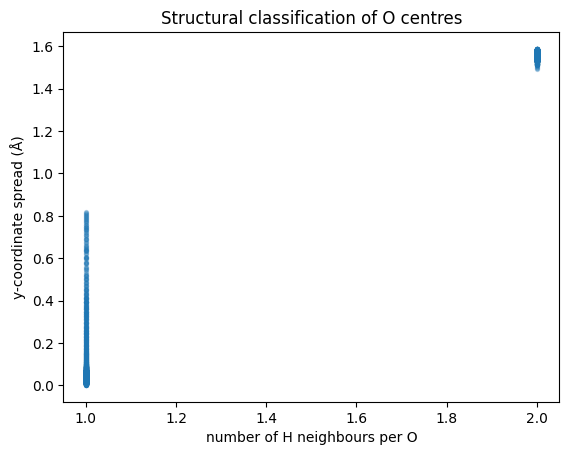

Approximate OH atoms: 1150
Approximate H2O atoms: 1212


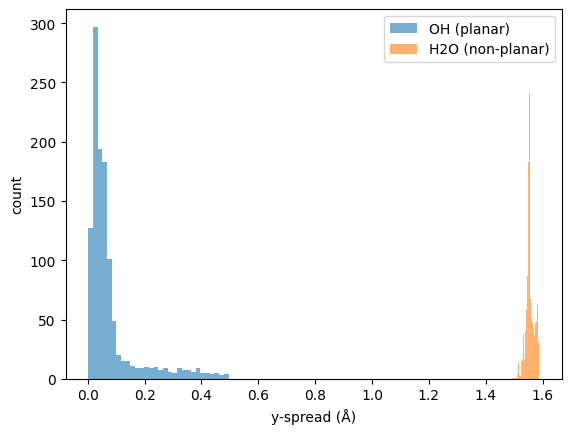

In [16]:
##-Store structural descriptors for each O centre-##
n_h_list = [] ##-Number of H atoms bound to each O-##
plane_spread = [] ##-y-coordinate spread of O + bonded H + nearest Pt-##

for atoms in traj:
  nl.update(atoms)

  cell = atoms.get_cell()
  pos = atoms.positions
  symbols = atoms.get_chemical_symbols()

  for i in range(n_atoms):
    if symbols[i] != 'O':
      continue

    idxs, offsets = nl.get_neighbors(i)

    if len(idxs) == 0:
      continue

    disp = pos[idxs] + offsets @ cell - pos[i]
    dists = np.linalg.norm(disp, axis=1)
    neigh_symbols = [symbols[j] for j in idxs]

    h_idx = [
      j for j, (s, d) in enumerate(zip(neigh_symbols, dists))
      if s == 'H' and d < 1.2
    ]

    pt_idx = [
      j for j, (s, d) in enumerate(zip(neigh_symbols, dists))
      if s == 'Pt' and d < 2.8
    ]

    n_h = len(h_idx)
    n_h_list.append(n_h)

    ##-Measure planarity using y-coordinate spread of O, bonded H and nearest Pt-##
    group_coords = [pos[i, 1]]
    group_coords += [pos[idxs[j], 1] for j in h_idx]

    if len(pt_idx) > 0:
      j = pt_idx[np.argmin(dists[pt_idx])]
      group_coords.append(pos[idxs[j], 1])

    if len(group_coords) > 1:
      spread_y = np.ptp(group_coords)
    else:
      spread_y = 0.0

    plane_spread.append(spread_y)

n_h_list = np.array(n_h_list)
plane_spread = np.array(plane_spread)

plt.scatter(n_h_list, plane_spread, s=8, alpha=0.3)
plt.xlabel('number of H neighbours per O')
plt.ylabel('y-coordinate spread (Å)')
plt.title('Structural classification of O centres')
plt.show()

##-Simple identification-##
is_oh = (n_h_list == 1) & (plane_spread < 0.5)
is_h2o = n_h_list == 2

print('Approximate OH atoms:', np.sum(is_oh))
print('Approximate H2O atoms:', np.sum(is_h2o))

plt.hist(plane_spread[is_oh], bins=30, alpha=0.6, label='OH (planar)')
plt.hist(plane_spread[is_h2o], bins=30, alpha=0.6, label='H2O (non-planar)')
plt.xlabel('y-spread (Å)')
plt.ylabel('count')
plt.legend()
plt.show()

This tests the trans-influence more directly: does a shorter Pt–O bond force the O–H bond to lengthen (and vice versa)? The negative correlation (r ≈ −0.14 for all O) is physically reasonable, when Pt binds OH more tightly, the O–H bond is slightly weakened. The filter pt_mask uses a tighter 1.9 Å cutoff to select only directly bonded Pt–O pairs.

Number of Pt-OH triplets (all O): 1176
Correlation(Pt-O length, O-H length) for all O = -0.21336354751679928
No data for O atoms with tag=4.


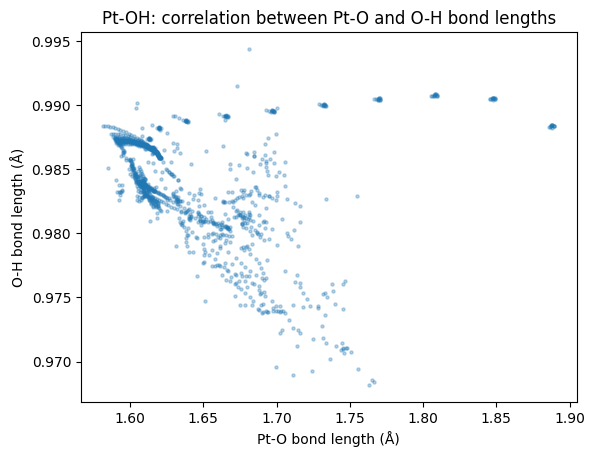

In [17]:
pt_o_lengths = []
o_h_lengths = []

pt_o_lengths_tag4 = []
o_h_lengths_tag4 = []

for atoms in traj:
  nl.update(atoms)

  cell = atoms.get_cell()
  pos = atoms.positions
  symbols = atoms.get_chemical_symbols()
  tags = atoms.get_tags()

  for i in range(n_atoms):
    if symbols[i] != 'O':
      continue

    idxs, offsets = nl.get_neighbors(i)

    if len(idxs) == 0:
      continue

    disp = pos[idxs] + offsets @ cell - pos[i]
    dists = np.linalg.norm(disp, axis=1)
    neigh_symbols = [symbols[j] for j in idxs]

    h_mask = np.array([
      s == 'H' and d < 1.1
      for s, d in zip(neigh_symbols, dists)
    ])

    pt_mask = np.array([
      s == 'Pt' and d < 1.9
      for s, d in zip(neigh_symbols, dists)
    ])

    h_indices = np.where(h_mask)[0]
    pt_indices = np.where(pt_mask)[0]

    if len(h_indices) == 1 and len(pt_indices) >= 1:
      jh = h_indices[0]
      d_oh = dists[jh]

      for jp in pt_indices:
        d_po = dists[jp]

        pt_o_lengths.append(d_po)
        o_h_lengths.append(d_oh)

        if tags[i] == 4:
          pt_o_lengths_tag4.append(d_po)
          o_h_lengths_tag4.append(d_oh)

pt_o_lengths = np.array(pt_o_lengths)
o_h_lengths = np.array(o_h_lengths)
pt_o_lengths_tag4 = np.array(pt_o_lengths_tag4)
o_h_lengths_tag4 = np.array(o_h_lengths_tag4)

print('Number of Pt-OH triplets (all O):', len(pt_o_lengths))

corr_all = np.corrcoef(pt_o_lengths, o_h_lengths)[0, 1]
print('Correlation(Pt-O length, O-H length) for all O =', corr_all)

if len(pt_o_lengths_tag4) > 1:
  print('Number of Pt-OH triplets (O tag=4):', len(pt_o_lengths_tag4))
  corr_tag4 = np.corrcoef(pt_o_lengths_tag4, o_h_lengths_tag4)[0, 1]
  print('Correlation(Pt-O length, O-H length) for O (tag=4) =', corr_tag4)
else:
  print('No data for O atoms with tag=4.')

plt.scatter(pt_o_lengths, o_h_lengths, s=5, alpha=0.3)
plt.scatter(pt_o_lengths_tag4, o_h_lengths_tag4, s=5, alpha=0.3)

plt.xlabel('Pt-O bond length (Å)')
plt.ylabel('O-H bond length (Å)')
plt.title('Pt-OH: correlation between Pt-O and O-H bond lengths')
plt.show()


This collects the speed (magnitude of velocity vector) of every water molecule atom across all frames and plots the distribution. At thermal equilibrium, you expect a Maxwell-Boltzmann speed distribution. Since the temperature is very low (10 K), the distribution should be narrow, a good verification that the thermostat is working correctly and the simulation is thermally consistent.


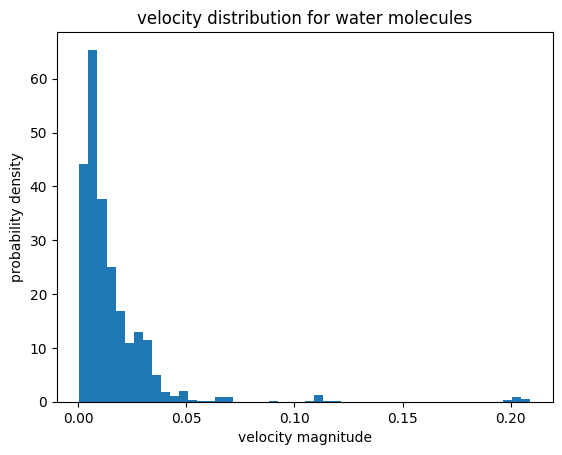

In [18]:
vel = []

for atoms in traj:
  v = atoms.get_velocities()

  if v is None:
    continue

  for i, atom in enumerate(atoms):
    if atom.tag == 4: ##-Water molecules-##
      vel.append(np.linalg.norm(v[i]))

vel = np.array(vel)

plt.hist(vel, bins=50, density=True)
plt.xlabel('velocity magnitude')
plt.ylabel('probability density')
plt.title('velocity distribution for water molecules')
plt.show()

## Summary

After completing this notebook, you should be able to:

1. Load a pre-trained calculator from a .pth file, attach it to an ASE Atoms object, freeze the two bottom slab layers with FixAtoms, initialize velocities with MaxwellBoltzmannDistribution, and run an NVT trajectory with the Bussi thermostat, logging energies and writing frames at regular intervals.
2. Explain why the bottom layers are frozen, why a thermostat is needed for NVT rather than NVE dynamics, why a 1 fs timestep is appropriate for this system, and why fixing the random seed is important for reproducibility.
3. Analyze structural correlations with neighbor lists. Use NeighborList with distance cutoffs to find Pt-O-H triplets, compute Pt-O-H angles and bond lengths across all frames, and quantify their correlation. Interpret a weak negative Pt-O vs O-H correlation as evidence of the trans-influence: tighter Pt-O binding slightly weakens the O-H bond.
4. Verify simulation quality. Plot the nearest-neighbor distance histogram to confirm no unphysical atomic overlaps or dissociation events occurred during the trajectory, and plot the velocity distribution of water molecule atoms to verify that it matches the expected narrow Maxwell-Boltzmann shape at 10 K, confirming the thermostat is working correctly.